In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix , classification_report , roc_auc_score , roc_curve
from sklearn.linear_model import LogisticRegression


In [76]:
# From previous notebbok we only need to drop the student_id column


student_df = pd.read_csv(r"C:\Users\Kxbuga\Desktop\student-performance-ml\data\Student_performance_data _.csv")
student_df = student_df.drop(['StudentID'] , axis = 1)
student_df

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [77]:
# you can check and see we have null values in thecolumns so we can go ahead and do classification of supervisedlearning

student_df.isnull().sum()

Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [78]:
# Supervised Learning

# Aim to predict the target values of unseen data given their features

# Of 2 types: Classification or Regression

# Classification - Target variable consists of categories eg : Passed exam based on certain subject marks
# Regression  - Target Variable is continous eg: Price of house based on certain features

In [79]:
# scikit learn syntax

# we import our model
# we instantiate our model
# we fit our model
# predict

In [80]:
# CLASSIFICATION

# Build a model
# Model learns from labeled data we pass to it
# pass unlabelled data as input
# model predicts the labels of unseen data

In [81]:
# In classification we use knearest neighbors model

# HOW IT WORKS

# Predict the label of a datapoint based on:
    # -> Look at the k closest label datapoint
    # -> Take a mojority vote

In [82]:
# we can try and see how studytime and gpa affect the gradeclass

# x values(features)  = study time and GPA
#  y value(target) = GradeClass

In [83]:
student_df_head = student_df.head(50)
student_df_head

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
5,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1.0
6,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2.0
7,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4.0
8,17,0,0,0,4.562008,1,0,2,0,1,0,1,2.896819,2.0
9,16,1,0,1,18.444466,0,0,3,1,0,0,0,3.573474,0.0


In [84]:
student_df_tail = student_df[['StudyTimeWeekly' , 'GPA']]
student_df_tail_reduced = student_df_tail.tail()

X_new = student_df_tail_reduced.values

print(X_new.shape)

(5, 2)


In [85]:
from sklearn.neighbors import KNeighborsClassifier

X = student_df_head[['StudyTimeWeekly' , 'GPA']].values
y = student_df_head['GradeClass'].values

print(X.shape , y.shape)

(50, 2) (50,)


In [86]:
# instantiate our model

knn = KNeighborsClassifier(n_neighbors = 5)

# fit our model

knn.fit(X , y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [87]:
# WE NEED DATA TO USE AND PREDICT
#  we will use the tail but we remove the last columns(target)

predictions = knn.predict(X_new)
print('Predictions: {}'.format(predictions))

Predictions: [3. 4. 4. 4. 2.]


In [88]:
# Our model based on the 50 values it learnt it predicted the last 5 rows as 3 , 4 , 4 , 4 , 2


# we can try and display our dataframe with the last 5 rows to see if thats our output

student_df.tail()

# Our datafRAME HAS 0 , 4 ,2 ,1 ,1

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0


In [89]:
# DISADVANTAGE OF FITTING THE CLASSIFIER ONLY

# wE CAN'T PREDICT HOW ACCURATE OUR MODEL IS

In [90]:
# We introduce a new concept to be able to predict our model accuracy

# Split data into: Training set and Test set

# Fit and / train our model based on the train set

# Calculate the accuracy using the test set

In [91]:
X = student_df[['StudyTimeWeekly' , 'GPA']].values
y = student_df['GradeClass'].values

In [92]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.3 , random_state = 21 , stratify = y)

# we intantiate our model

knn = KNeighborsClassifier(n_neighbors = 5)

# we fit our model using train data

knn.fit(X_train , y_train)

# print the score prediction of our model

print(knn.score(X_test , y_test))

0.8565459610027855


In [93]:
# Our model is 84 percent accurate

In [94]:
# This is not very accuarate either due to underfiiting or overfitting

# underfitting = WHEN WE HAVE A LARGER K , LESS COMPLEX MODEL

# overfitting = WHEN WE HAVE A LESSER K , MORE COMPLEX MODEL

In [95]:
# To solve this to know which k value is more acccurate:


# we record each value of train and test in their own dictionaries

# We loop within arrange of maybe 1 to 26



In [96]:
train_accuracies = {}
test_accuracies = {}

neighbors = np.arange(1 , 26)

# create a for loop to loop through the neighbors values from 1 to 26

for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors = neighbor ) #instead of fitting a random k value we fit the range
    knn.fit(X_train , y_train) # fit our model
    train_accuracies[neighbor] = knn.score(X_train , y_train)
    test_accuracies[neighbor] = knn.score(X_test , y_test)
    
    # we print the values of k both the trainaccuracy and testaccuracy

    print(f"K = {neighbor} -> Train_accuarcy = {train_accuracies} -> Test_accuracy = {test_accuracies}")





K = 1 -> Train_accuarcy = {np.int64(1): 1.0} -> Test_accuracy = {np.int64(1): 0.8119777158774373}
K = 2 -> Train_accuarcy = {np.int64(1): 1.0, np.int64(2): 0.9068100358422939} -> Test_accuracy = {np.int64(1): 0.8119777158774373, np.int64(2): 0.7618384401114207}
K = 3 -> Train_accuarcy = {np.int64(1): 1.0, np.int64(2): 0.9068100358422939, np.int64(3): 0.9109916367980884} -> Test_accuracy = {np.int64(1): 0.8119777158774373, np.int64(2): 0.7618384401114207, np.int64(3): 0.8314763231197771}
K = 4 -> Train_accuarcy = {np.int64(1): 1.0, np.int64(2): 0.9068100358422939, np.int64(3): 0.9109916367980884, np.int64(4): 0.8942652329749103} -> Test_accuracy = {np.int64(1): 0.8119777158774373, np.int64(2): 0.7618384401114207, np.int64(3): 0.8314763231197771, np.int64(4): 0.8286908077994429}
K = 5 -> Train_accuarcy = {np.int64(1): 1.0, np.int64(2): 0.9068100358422939, np.int64(3): 0.9109916367980884, np.int64(4): 0.8942652329749103, np.int64(5): 0.8954599761051374} -> Test_accuracy = {np.int64(1): 0.

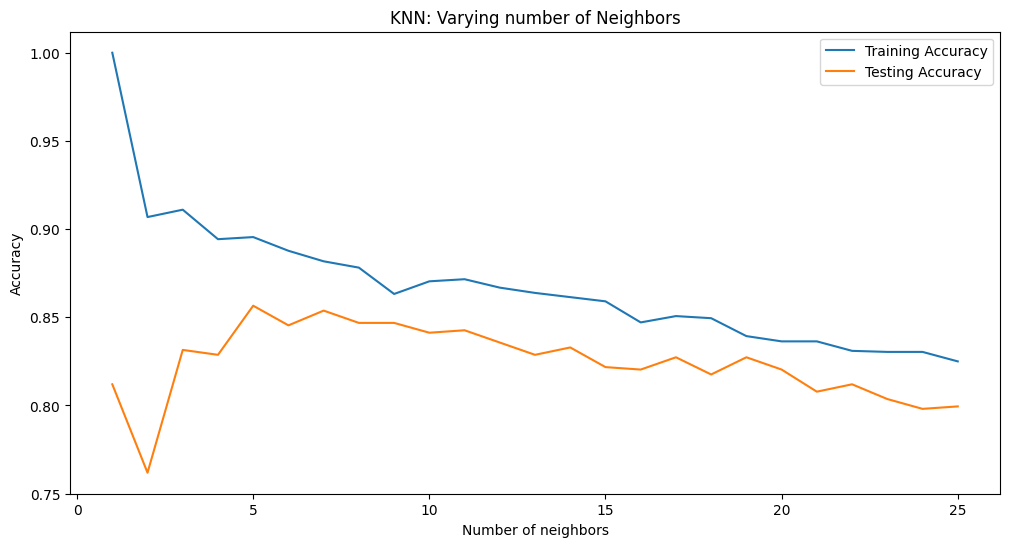

In [97]:
# Difficult to understand that way so we visualize

plt.figure(figsize = (12 , 6))
plt.title("KNN: Varying number of Neighbors")
plt.plot(neighbors , train_accuracies.values() , label = 'Training Accuracy')
plt.plot(neighbors , test_accuracies.values() , label = 'Testing Accuracy')
plt.legend()
plt.xlabel("Number of neighbors")
plt.ylabel('Accuracy')
plt.show()

In [98]:
# Model is most accurate when the value of k is around 5 or 6

# test is higher there same as train

In [99]:
# CONFUSION MATRIX

Text(50.722222222222214, 0.5, 'Actual Grade')

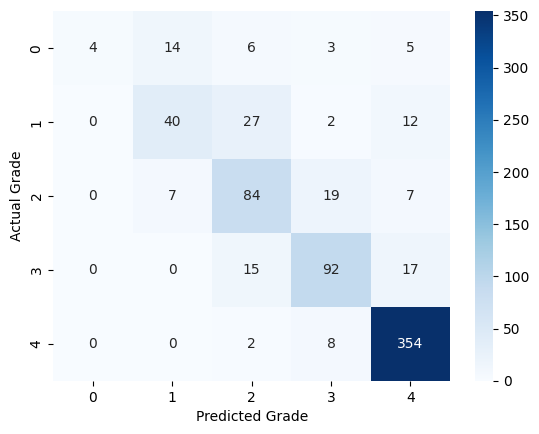

In [100]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test , y_pred)

# Difficult to visualizze so we draw a heatmap

sns.heatmap(cm , annot = True , fmt = 'd' , cmap = 'Blues')
plt.xlabel("Predicted Grade")
plt.ylabel('Actual Grade')

In [101]:
# we explain our heatmap

# The heat map is a 5 by 5 matrix

# tHE DIAGNONAL LINE FROM TOP LLEFT TO BOTTOM RIGHT INDICATE THE TRUE POSITIVES

# TRUE POSITIVES(4, 40 , 84 , 92 , 354)

# LETS INTERPRET FOR GRADE 4

# GRADE 4 we have: 
# True positive = 354 (The model was able to crrectly identify 354 students out of the possible 362)
# False Positives = 5 , 12 , 7 , 17(Those that were classified as Grade 4 yet they dont belon there)

# We follow the same preocedure when we want to interepret the results of the other grades


# GRADE 4

# RECALL = 354 / 364 = 97 PERCENT ACCURACY (the model was able to correctly identify almost 97 percent accurate. Its done a pretty good job in identifying the number of true positvies)

# If the number of false negatives were high(Like the number of students who had a grade 4 are wrongly classified ) the recall would be low

# PRECISION = 354 / 395(354 + outliers) = 90 PERCENT .(The model was able to classify 90 percent students correctly. The remaining 10 percent are not supposed to be in grade 4 )

# Its f1 score is even better because its the haramonic mean of the precion and recall and its pretty high. So the model is doing pretty well in predicting students who have a grade 4

# If we were to get a high precision like now it mmeans that we dont have alot of false positives(There are not alot of students who have been classified as grade 4 and they are not supposed to be here)


In [102]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.12      0.22        32
         1.0       0.66      0.49      0.56        81
         2.0       0.63      0.72      0.67       117
         3.0       0.74      0.74      0.74       124
         4.0       0.90      0.97      0.93       364

    accuracy                           0.80       718
   macro avg       0.78      0.61      0.63       718
weighted avg       0.80      0.80      0.78       718



In [103]:
# LET US INTERPRET THE FOLLOWING RESULTS

# Model overall accuracy is = 80 percent

# Alot of the percentage is being contributed alot by the grade 4. So if we were to try and predict the other classes specifically the lower classes(grade 1 and 2) it would do a poor job in predicting that.

# Macro average(0.61) - Treats every grade as equal regardless of how many students are in it

# In an imbalanced dataset we look at the Macro avg. A macro avg in recall of 0.61 tells us that the model can correctly identify 60 percent students in their correct classes without reliance on the easy majority classes

# Weighted Precision (0.80): "Overall, 80% of the model's predictions are correct. This is high because the model is very good at the majority class (Grade 4.0)."

# Macro Precision (0.78): "On average, across all 5 grade levels, the model is 78% precise. However, the low Macro Recall (0.61) reveals that the model is struggling to actually find the students in the smaller grade classes (like Grade 0.0)."


In [104]:
# We calculate the roc_auc_score , confusion matrix and classification matrix of the knn model we created


y_probs = knn.predict_proba(X_test)[: , 1]

auc = roc_auc_score(y_test, knn.predict_proba(X_test), multi_class='ovr', average='macro')
print(f"ROC AUC: {auc}")


# confusion matrix

print(confusion_matrix(y_test , y_pred))

# classification report
print(classification_report(y_test , y_pred))

ROC AUC: 0.8845488100466016
[[  4  14   6   3   5]
 [  0  40  27   2  12]
 [  0   7  84  19   7]
 [  0   0  15  92  17]
 [  0   0   2   8 354]]
              precision    recall  f1-score   support

         0.0       1.00      0.12      0.22        32
         1.0       0.66      0.49      0.56        81
         2.0       0.63      0.72      0.67       117
         3.0       0.74      0.74      0.74       124
         4.0       0.90      0.97      0.93       364

    accuracy                           0.80       718
   macro avg       0.78      0.61      0.63       718
weighted avg       0.80      0.80      0.78       718



In [105]:
# we use logistic regression model and compare with knn

# We have already split our data we wiil instantiate our model


lr_model = LogisticRegression(max_iter=1000)

# fit our model

lr_model.fit(X_train , y_train)

# predict

y_new_pred = lr_model.predict(X_test)


# get the probabilities

logistic_prob = lr_model.predict_proba(X_test)

# auc score

log_auc = roc_auc_score(y_test , logistic_prob , multi_class = 'ovr' , average = 'macro')
print(f"ROC AUC: {log_auc}")

# confusion matrix

print(confusion_matrix(y_test , y_new_pred))

# classification report

print(classification_report(y_test , y_new_pred))

ROC AUC: 0.908552345776753
[[  0  19   4   4   5]
 [  0  50  17   2  12]
 [  0   0 107   2   8]
 [  0   1   8  99  16]
 [  0   0   1   4 359]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        32
         1.0       0.71      0.62      0.66        81
         2.0       0.78      0.91      0.84       117
         3.0       0.89      0.80      0.84       124
         4.0       0.90      0.99      0.94       364

    accuracy                           0.86       718
   macro avg       0.66      0.66      0.66       718
weighted avg       0.82      0.86      0.83       718



c:\Users\Kxbuga\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kxbuga\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kxbuga\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

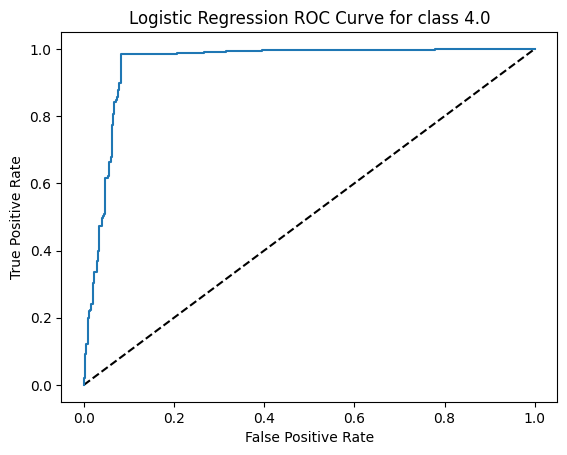

In [110]:
target_class = 4.0
class_index = np.where(lr_model.classes_ == target_class)[0][0]

one_class = lr_model.predict_proba(X_test)[:, class_index]
y_test_binary = (y_test == target_class).astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary, one_class)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Logistic Regression ROC Curve for class {target_class}")
plt.show()